# Исследование обобщающей способности Logistic Regression

Цель блокнота — выбрать конфигурацию LogReg, которая с наибольшей вероятностью
обобщится на hidden private, а не случайно победит на одном public split.

Архитектура решения:

1. единый preprocessing и единые folds пользователей для всех девяти продуктов;
2. отдельная бинарная Logistic Regression для каждого продукта;
3. общая OOF-матрица вероятностей размера `n_users x 9`;
4. основной критерий — pooled/micro ROC-AUC, дополнительные — macro и per-product AUC;
5. широкий скрининг на одном seed, repeated OOF для финалистов и подтверждение на новых seed;
6. индивидуальный `C` по продуктам и stacking проверяются только через nested CV;
7. при статистически эквивалентных результатах выбирается более простая модель.

По умолчанию включен `FAST_MODE`: он выполняет smoke-версию исследования.
Для полноценного прогона установите переменную окружения
`LOGREG_RESEARCH_FULL=1` перед запуском ядра.

## 1. Импорты и конфигурация

В полном режиме широкий поиск остается намеренно ограниченным. Задача этого
исследования — надежно различить несколько правдоподобных линейных решений,
а не провести неограниченный hyperparameter search.

In [1]:
from __future__ import annotations

import json
import os
import time
import warnings
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA_PATH = Path("../train_weRmhWx.csv")
ARTIFACT_DIR = Path("./models")

PRODUCTS = [
    "credit_card", "mortgage", "deposit", "investment", "insurance",
    "p2p_transfer", "cashback", "premium_account", "business_loan",
]
TARGETS = [f"product_{product}" for product in PRODUCTS]
ALL_FEATURES = [
    "age", "income_bucket", "tenure_months", "tx_count_30d",
    "avg_tx_amount", "digital_activity_score", "has_child", "is_salary_client",
]
STRONG_FEATURES = [
    "income_bucket", "digital_activity_score", "has_child", "is_salary_client",
]

FAST_MODE = os.getenv("LOGREG_RESEARCH_FULL", "0") != "1"
SAMPLE_SIZE = 12_000 if FAST_MODE else None
BROAD_FOLDS = 3 if FAST_MODE else 5
BROAD_SEED = 42
REPEAT_FOLDS = 3 if FAST_MODE else 5
REPEAT_SEEDS = [7, 42] if FAST_MODE else [7, 13, 42, 123, 2026]
CONFIRM_SEEDS = [] if FAST_MODE else [27182, 31415]
TOP_K = 2 if FAST_MODE else 4
EQUIVALENCE_MARGIN = 0.0005
BOOTSTRAP_ROUNDS = 30 if FAST_MODE else 200
RUN_NESTED_PRODUCT_SEARCH = not FAST_MODE
RUN_NESTED_STACKING = not FAST_MODE
EXPORT_FINAL_MODEL = False
RANDOM_STATE = 2026

print({
    "fast_mode": FAST_MODE,
    "sample_size": SAMPLE_SIZE,
    "broad_folds": BROAD_FOLDS,
    "repeat_seeds": REPEAT_SEEDS,
    "nested_product_search": RUN_NESTED_PRODUCT_SEARCH,
    "nested_stacking": RUN_NESTED_STACKING,
})

{'fast_mode': False, 'sample_size': None, 'broad_folds': 5, 'repeat_seeds': [7, 13, 42, 123, 2026], 'nested_product_search': True, 'nested_stacking': True}


## 2. Загрузка и контроль данных

Проверки ниже являются частью контракта исследования. При изменении схемы,
появлении пропусков или дубликатов эксперимент должен остановиться, а не
молча продолжить работу на другом наборе данных.

In [2]:
df_full = pd.read_csv(DATA_PATH)

required_columns = {"user_id", *ALL_FEATURES, *TARGETS}
missing_columns = sorted(required_columns - set(df_full.columns))
assert not missing_columns, f"Missing columns: {missing_columns}"
assert df_full["user_id"].is_unique, "user_id must be unique"
assert not df_full[ALL_FEATURES + TARGETS].isna().any().any(), "Unexpected missing values"
assert set(np.unique(df_full[TARGETS].to_numpy())) <= {0, 1}, "Targets must be binary"

if SAMPLE_SIZE and len(df_full) > SAMPLE_SIZE:
    df = df_full.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df = df_full.copy()

X = df[ALL_FEATURES].copy()
X["has_child"] = X["has_child"].astype(int)
X["is_salary_client"] = X["is_salary_client"].astype(int)
Y = df[TARGETS].to_numpy(dtype=np.int8)

dataset_summary = pd.DataFrame({
    "rows": [len(df)],
    "features": [len(ALL_FEATURES)],
    "targets": [len(TARGETS)],
    "duplicates": [int(df.duplicated().sum())],
    "missing_values": [int(df.isna().sum().sum())],
})
display(dataset_summary)
display(pd.Series(Y.mean(axis=0), index=PRODUCTS, name="positive_rate").to_frame())

,rows,features,targets,duplicates,missing_values
0,70000,8,9,0,0


,positive_rate
credit_card,0.495557
mortgage,0.492400
deposit,0.499000
investment,0.496714
insurance,0.497886
p2p_transfer,0.491857
cashback,0.489629
premium_account,0.499371
business_loan,0.498214


## 3. Конфигурация модели и единые folds

Все девять моделей получают одни и те же train/validation индексы. Если
доступен пакет `iterative-stratification`, используется multilabel
stratification. В стандартном окружении применяется shuffled `KFold`;
при 70 000 строках и сбалансированных таргетах он дает стабильные доли классов.

Scaler или encoder всегда обучается только на train-части fold.

In [3]:
@dataclass(frozen=True)
class ModelSpec:
    name: str
    C: float = 1.0
    class_weight: str | None = None
    penalty: str = "l2"
    l1_ratio: float | None = None
    feature_set: str = "all"
    income_encoding: str = "ordinal"


def selected_features(spec: ModelSpec) -> list[str]:
    if spec.feature_set == "all":
        return ALL_FEATURES
    if spec.feature_set == "strong":
        return STRONG_FEATURES
    raise ValueError(f"Unknown feature_set={spec.feature_set}")


def make_transformer(spec: ModelSpec):
    features = selected_features(spec)
    if spec.income_encoding == "ordinal":
        return StandardScaler()
    if spec.income_encoding == "onehot":
        numeric = [column for column in features if column != "income_bucket"]
        return ColumnTransformer(
            transformers=[
                ("numeric", StandardScaler(), numeric),
                (
                    "income",
                    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ["income_bucket"],
                ),
            ],
            remainder="drop",
        )
    raise ValueError(f"Unknown income_encoding={spec.income_encoding}")


def make_model(spec: ModelSpec, *, C: float | None = None, seed: int = 42):
    solver = "lbfgs"
    penalty_kwargs = {}
    sklearn_version = tuple(int(part) for part in sklearn.__version__.split(".")[:2])
    if spec.penalty == "l1":
        solver = "saga"
        if sklearn_version >= (1, 8):
            penalty_kwargs["l1_ratio"] = 1.0
        else:
            penalty_kwargs["penalty"] = "l1"
    elif spec.penalty == "elasticnet":
        solver = "saga"
        penalty_kwargs["l1_ratio"] = spec.l1_ratio
        if sklearn_version < (1, 8):
            penalty_kwargs["penalty"] = "elasticnet"

    return LogisticRegression(
        C=spec.C if C is None else C,
        solver=solver,
        class_weight=spec.class_weight,
        max_iter=2_000,
        random_state=seed,
        **penalty_kwargs,
    )


def make_common_splits(y: np.ndarray, n_splits: int, seed: int):
    try:
        from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

        splitter = MultilabelStratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed,
        )
        method = "MultilabelStratifiedKFold"
        splits = list(splitter.split(np.zeros(len(y)), y))
    except ImportError:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        method = "KFold fallback"
        splits = list(splitter.split(np.zeros(len(y))))
    return splits, method


fold_preview, fold_method = make_common_splits(Y, BROAD_FOLDS, BROAD_SEED)
fold_balance = []
for fold, (_, valid_idx) in enumerate(fold_preview):
    row = {"fold": fold, "rows": len(valid_idx)}
    row.update(dict(zip(PRODUCTS, Y[valid_idx].mean(axis=0))))
    fold_balance.append(row)

print("Fold method:", fold_method)
display(pd.DataFrame(fold_balance).round(4))

Fold method: KFold fallback


,fold,rows,credit_card,mortgage,deposit,investment,insurance,p2p_transfer,cashback,premium_account,business_loan
0,0,14000,0.4931,0.4928,0.5016,0.4990,0.4996,0.4926,0.4831,0.4910,0.4956
1,1,14000,0.5010,0.4856,0.5030,0.4939,0.4911,0.4912,0.4973,0.5018,0.4952
2,2,14000,0.4944,0.4944,0.5013,0.4987,0.5013,0.4910,0.4946,0.4980,0.4999
3,3,14000,0.4887,0.4858,0.4919,0.4974,0.4981,0.4914,0.4868,0.5050,0.4978
4,4,14000,0.5006,0.5034,0.4971,0.4946,0.4993,0.4931,0.4864,0.5011,0.5025


## 4. OOF engine

Один transformer обучается внутри fold и используется всеми продуктовыми
моделями. Это сохраняет единый preprocessing, но коэффициенты и intercept
остаются отдельными для каждого продукта.

In [4]:
def score_oof(y_true: np.ndarray, predictions: np.ndarray):
    per_product = {
        product: roc_auc_score(y_true[:, index], predictions[:, index])
        for index, product in enumerate(PRODUCTS)
    }
    return {
        "micro_auc": roc_auc_score(y_true.ravel(), predictions.ravel()),
        "macro_auc": float(np.mean(list(per_product.values()))),
        "per_product": per_product,
    }


def fit_predict_fold(
    x_train: pd.DataFrame,
    y_train: np.ndarray,
    x_valid: pd.DataFrame,
    spec: ModelSpec,
    *,
    seed: int,
    product_cs: dict[str, float] | None = None,
):
    features = selected_features(spec)
    transformer = make_transformer(spec)
    train_matrix = transformer.fit_transform(x_train[features])
    valid_matrix = transformer.transform(x_valid[features])

    predictions = np.zeros((len(x_valid), len(PRODUCTS)), dtype=np.float64)
    for product_index, product in enumerate(PRODUCTS):
        selected_c = None if product_cs is None else product_cs[product]
        model = make_model(spec, C=selected_c, seed=seed)
        model.fit(train_matrix, y_train[:, product_index])
        predictions[:, product_index] = model.predict_proba(valid_matrix)[:, 1]
    return predictions


def evaluate_spec(
    x: pd.DataFrame,
    y: np.ndarray,
    spec: ModelSpec,
    *,
    seeds: list[int],
    n_splits: int,
    keep_oof: bool = False,
):
    run_rows = []
    product_rows = []
    oof_by_seed = {}

    for seed in seeds:
        started = time.perf_counter()
        splits, method = make_common_splits(y, n_splits, seed)
        oof = np.zeros_like(y, dtype=np.float64)

        for fold, (train_idx, valid_idx) in enumerate(splits):
            oof[valid_idx] = fit_predict_fold(
                x.iloc[train_idx],
                y[train_idx],
                x.iloc[valid_idx],
                spec,
                seed=seed + fold,
            )

        metrics = score_oof(y, oof)
        run_rows.append({
            "model": spec.name,
            "seed": seed,
            "fold_method": method,
            "micro_auc": metrics["micro_auc"],
            "macro_auc": metrics["macro_auc"],
            "seconds": time.perf_counter() - started,
        })
        product_rows.extend({
            "model": spec.name,
            "seed": seed,
            "product": product,
            "auc": auc,
        } for product, auc in metrics["per_product"].items())
        if keep_oof:
            oof_by_seed[seed] = oof

    return pd.DataFrame(run_rows), pd.DataFrame(product_rows), oof_by_seed


def summarize_runs(run_frame: pd.DataFrame):
    aggregations = {
        "micro_mean": ("micro_auc", "mean"),
        "micro_std": ("micro_auc", "std"),
        "micro_min": ("micro_auc", "min"),
        "micro_max": ("micro_auc", "max"),
        "macro_mean": ("macro_auc", "mean"),
    }
    if "seconds" in run_frame.columns:
        aggregations["seconds"] = ("seconds", "sum")
    return (
        run_frame.groupby("model", as_index=False)
        .agg(**aggregations)
        .fillna({"micro_std": 0.0})
        .sort_values(["micro_mean", "micro_std"], ascending=[False, True])
        .reset_index(drop=True)
    )

## 5. Этап A: широкий скрининг

Скрининг использует один seed. Его задача — удалить явно слабые варианты,
а не объявить победителя. В полном режиме проверяются регуляризация,
`class_weight`, кодирование `income_bucket`, набор признаков и тип penalty.

In [5]:
def build_search_space(fast_mode: bool):
    specs = [
        ModelSpec(name=f"ordinal_all_l2_C{c:g}", C=c)
        for c in ([0.03, 1.0] if fast_mode else [0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0])
    ]
    specs.extend([
        ModelSpec(name="ordinal_all_balanced_C1", C=1.0, class_weight="balanced"),
        ModelSpec(name="onehot_all_l2_C1", C=1.0, income_encoding="onehot"),
    ])
    if not fast_mode:
        specs.extend([
            ModelSpec(name="ordinal_strong_l2_C0.03", C=0.03, feature_set="strong"),
            ModelSpec(name="ordinal_strong_l2_C1", C=1.0, feature_set="strong"),
            ModelSpec(name="onehot_all_l2_C0.03", C=0.03, income_encoding="onehot"),
            ModelSpec(name="ordinal_all_l1_C0.03", C=0.03, penalty="l1"),
            ModelSpec(name="ordinal_all_l1_C1", C=1.0, penalty="l1"),
            ModelSpec(
                name="ordinal_all_elastic_C0.03",
                C=0.03,
                penalty="elasticnet",
                l1_ratio=0.5,
            ),
        ])
    return specs


SEARCH_SPECS = build_search_space(FAST_MODE)
SPEC_BY_NAME = {spec.name: spec for spec in SEARCH_SPECS}
display(pd.DataFrame([asdict(spec) for spec in SEARCH_SPECS]))

broad_runs = []
broad_products = []
for spec in SEARCH_SPECS:
    print("Screening:", spec.name)
    runs, products, _ = evaluate_spec(
        X,
        Y,
        spec,
        seeds=[BROAD_SEED],
        n_splits=BROAD_FOLDS,
    )
    broad_runs.append(runs)
    broad_products.append(products)

broad_runs = pd.concat(broad_runs, ignore_index=True)
broad_products = pd.concat(broad_products, ignore_index=True)
broad_summary = summarize_runs(broad_runs)
display(broad_summary.round(6))

,name,C,class_weight,penalty,l1_ratio,feature_set,income_encoding
0,ordinal_all_l2_C0.003,0.003,NaN,l2,NaN,all,ordinal
1,ordinal_all_l2_C0.01,0.010,NaN,l2,NaN,all,ordinal
2,ordinal_all_l2_C0.03,0.030,NaN,l2,NaN,all,ordinal
3,ordinal_all_l2_C0.1,0.100,NaN,l2,NaN,all,ordinal
4,ordinal_all_l2_C0.3,0.300,NaN,l2,NaN,all,ordinal
5,ordinal_all_l2_C1,1.000,NaN,l2,NaN,all,ordinal
6,ordinal_all_l2_C3,3.000,NaN,l2,NaN,all,ordinal
7,ordinal_all_l2_C10,10.000,NaN,l2,NaN,all,ordinal
8,ordinal_all_balanced_C1,1.000,balanced,l2,NaN,all,ordinal
9,onehot_all_l2_C1,1.000,NaN,l2,NaN,all,onehot


Screening: ordinal_all_l2_C0.003


Screening: ordinal_all_l2_C0.01


Screening: ordinal_all_l2_C0.03


Screening: ordinal_all_l2_C0.1


...

Screening: onehot_all_l2_C0.03


Screening: ordinal_all_l1_C0.03


Screening: ordinal_all_l1_C1


Screening: ordinal_all_elastic_C0.03


,model,micro_mean,micro_std,micro_min,micro_max,macro_mean,seconds
0,ordinal_all_l1_C0.03,0.670292,0.0,0.670292,0.670292,0.658321,2.079088
1,ordinal_all_elastic_C0.03,0.670274,0.0,0.670274,0.670274,0.658306,2.193184
2,ordinal_all_l1_C1,0.670254,0.0,0.670254,0.670254,0.658288,2.246248
3,ordinal_strong_l2_C1,0.670254,0.0,0.670254,0.670254,0.658121,0.360373
4,ordinal_strong_l2_C0.03,0.670254,0.0,0.670254,0.670254,0.658120,0.362201
5,ordinal_all_l2_C10,0.670253,0.0,0.670253,0.670253,0.658287,0.369445
6,ordinal_all_l2_C3,0.670253,0.0,0.670253,0.670253,0.658287,0.381233
7,ordinal_all_l2_C1,0.670253,0.0,0.670253,0.670253,0.658287,0.369029
8,ordinal_all_l2_C0.3,0.670253,0.0,0.670253,0.670253,0.658287,0.370044
9,ordinal_all_l2_C0.1,0.670253,0.0,0.670253,0.670253,0.658287,0.369498


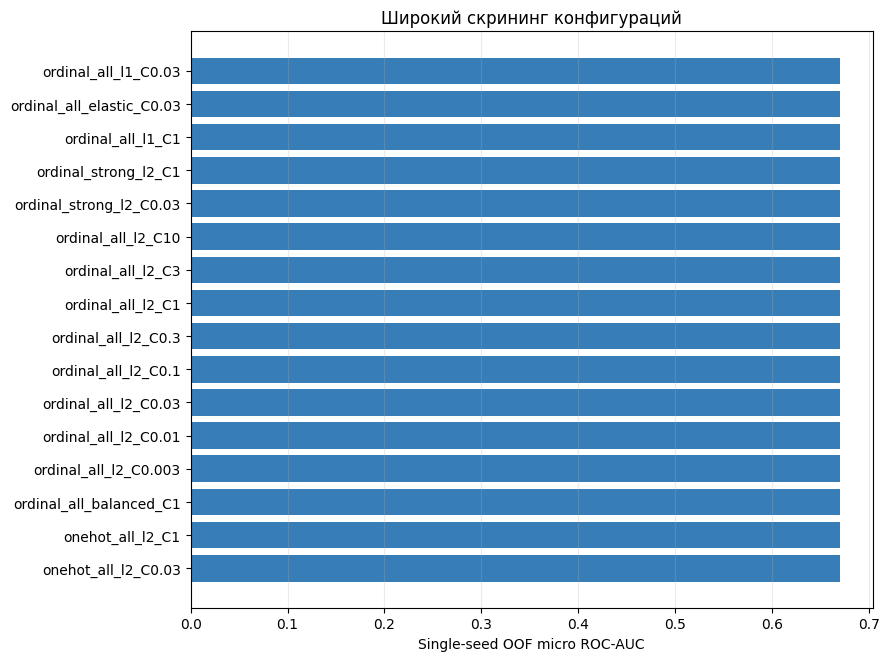

In [6]:
plot_frame = broad_summary.sort_values("micro_mean")
fig, ax = plt.subplots(figsize=(9, max(4, len(plot_frame) * 0.42)))
ax.barh(plot_frame["model"], plot_frame["micro_mean"], color="#377eb8")
ax.set_xlabel("Single-seed OOF micro ROC-AUC")
ax.set_title("Широкий скрининг конфигураций")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Этап B: repeated OOF для финалистов

В repeated-этап проходят только лучшие кандидаты скрининга. Базовый
`ordinal_all_l2_C0.03` добавляется принудительно, чтобы сравнение всегда
содержало простой private-safe ориентир.

In [7]:
top_names = broad_summary.head(TOP_K)["model"].tolist()
baseline_name = "ordinal_all_l2_C0.03"
if baseline_name in SPEC_BY_NAME and baseline_name not in top_names:
    top_names.append(baseline_name)

finalist_specs = [SPEC_BY_NAME[name] for name in dict.fromkeys(top_names)]
print("Finalists:", [spec.name for spec in finalist_specs])

repeated_runs = []
repeated_products = []
repeated_oof = {}

for spec in finalist_specs:
    print("Repeated OOF:", spec.name)
    runs, products, oof = evaluate_spec(
        X,
        Y,
        spec,
        seeds=REPEAT_SEEDS,
        n_splits=REPEAT_FOLDS,
        keep_oof=True,
    )
    repeated_runs.append(runs)
    repeated_products.append(products)
    repeated_oof[spec.name] = oof

repeated_runs = pd.concat(repeated_runs, ignore_index=True)
repeated_products = pd.concat(repeated_products, ignore_index=True)
repeated_summary = summarize_runs(repeated_runs)
display(repeated_summary.round(6))

Finalists: ['ordinal_all_l1_C0.03', 'ordinal_all_elastic_C0.03', 'ordinal_all_l1_C1', 'ordinal_strong_l2_C1', 'ordinal_all_l2_C0.03']
Repeated OOF: ordinal_all_l1_C0.03


Repeated OOF: ordinal_all_elastic_C0.03


Repeated OOF: ordinal_all_l1_C1


Repeated OOF: ordinal_strong_l2_C1


Repeated OOF: ordinal_all_l2_C0.03


,model,micro_mean,micro_std,micro_min,micro_max,macro_mean,seconds
0,ordinal_all_l1_C0.03,0.670319,0.000020,0.670292,0.670340,0.658365,10.429914
1,ordinal_all_elastic_C0.03,0.670304,0.000020,0.670274,0.670324,0.658357,11.021336
2,ordinal_strong_l2_C1,0.670296,0.000029,0.670254,0.670325,0.658216,1.811459
3,ordinal_all_l1_C1,0.670287,0.000021,0.670254,0.670307,0.658344,11.412145
4,ordinal_all_l2_C0.03,0.670285,0.000021,0.670253,0.670305,0.658343,1.863516


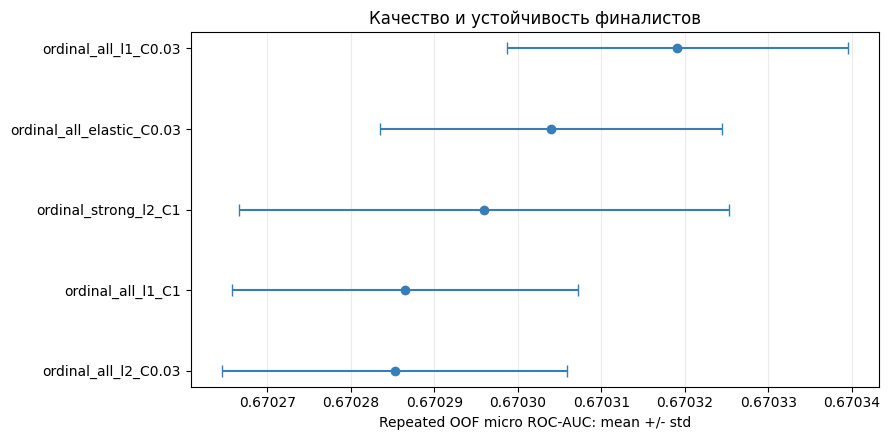

model,ordinal_all_elastic_C0.03,ordinal_all_l1_C0.03,ordinal_all_l1_C1,ordinal_all_l2_C0.03,ordinal_strong_l2_C1
product,,,,,
business_loan,0.67079,0.67078,0.67079,0.67080,0.67084
cashback,0.57579,0.57580,0.57578,0.57577,0.57573
credit_card,0.71385,0.71387,0.71383,0.71383,0.71391
deposit,0.56364,0.56368,0.56360,0.56360,0.56366
insurance,0.68664,0.68663,0.68664,0.68664,0.68596
investment,0.66854,0.66855,0.66853,0.66853,0.66847
mortgage,0.77795,0.77791,0.77798,0.77798,0.77745
p2p_transfer,0.58178,0.58182,0.58174,0.58174,0.58166
premium_account,0.68623,0.68625,0.68621,0.68621,0.68627


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
chart = repeated_summary.sort_values("micro_mean")
ax.errorbar(
    chart["micro_mean"],
    chart["model"],
    xerr=chart["micro_std"],
    fmt="o",
    capsize=4,
    color="#377eb8",
)
ax.set_xlabel("Repeated OOF micro ROC-AUC: mean +/- std")
ax.set_title("Качество и устойчивость финалистов")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

product_pivot = (
    repeated_products.groupby(["model", "product"], as_index=False)["auc"].mean()
    .pivot(index="product", columns="model", values="auc")
)
display(product_pivot.round(5))

## 7. Парное сравнение и неопределенность

Bootstrap выполняется по пользователям: все девять таргетов пользователя
попадают в bootstrap sample вместе. Это сохраняет структуру multilabel-задачи.
Сравнение парное, поэтому измеряет именно разницу двух моделей на одинаковых
объектах.

In [9]:
def paired_user_bootstrap(
    y_true: np.ndarray,
    pred_a: np.ndarray,
    pred_b: np.ndarray,
    *,
    rounds: int,
    seed: int = 2026,
):
    rng = np.random.default_rng(seed)
    differences = []
    for _ in range(rounds):
        indices = rng.integers(0, len(y_true), size=len(y_true))
        auc_a = roc_auc_score(y_true[indices].ravel(), pred_a[indices].ravel())
        auc_b = roc_auc_score(y_true[indices].ravel(), pred_b[indices].ravel())
        differences.append(auc_a - auc_b)
    values = np.asarray(differences)
    return {
        "mean_delta": values.mean(),
        "p05": np.quantile(values, 0.05),
        "p50": np.quantile(values, 0.50),
        "p95": np.quantile(values, 0.95),
        "probability_a_better": np.mean(values > 0),
    }


mean_winner = repeated_summary.iloc[0]["model"]
comparison_baseline = baseline_name if baseline_name in repeated_oof else repeated_summary.iloc[-1]["model"]
comparison_seed = REPEAT_SEEDS[0]

bootstrap_result = paired_user_bootstrap(
    Y,
    repeated_oof[mean_winner][comparison_seed],
    repeated_oof[comparison_baseline][comparison_seed],
    rounds=BOOTSTRAP_ROUNDS,
)
display(pd.DataFrame([{
    "candidate": mean_winner,
    "baseline": comparison_baseline,
    **bootstrap_result,
}]).round(6))

,candidate,baseline,mean_delta,p05,p50,p95,probability_a_better
0,ordinal_all_l1_C0.03,ordinal_all_l2_C0.03,0.000035,0.000023,0.000034,0.000049,1.0


## 8. Диагностика остаточной зависимости продуктов

Если после базовых моделей остаточные корреляции близки к нулю, метамодель
не имеет устойчивого сигнала для использования зависимостей между продуктами.

In [10]:
diagnostic_predictions = repeated_oof[mean_winner][comparison_seed]
residuals = Y - diagnostic_predictions
residual_corr = pd.DataFrame(
    np.corrcoef(residuals, rowvar=False),
    index=PRODUCTS,
    columns=PRODUCTS,
)
off_diagonal = residual_corr.to_numpy()[~np.eye(len(PRODUCTS), dtype=bool)]

print("Maximum absolute residual correlation:", float(np.max(np.abs(off_diagonal))))
display(residual_corr.round(3))

Maximum absolute residual correlation: 0.0067133935719311194


,credit_card,mortgage,deposit,investment,insurance,p2p_transfer,cashback,premium_account,business_loan
credit_card,1.000,-0.003,0.000,-0.001,0.001,-0.005,0.001,-0.006,0.004
mortgage,-0.003,1.000,-0.002,-0.004,0.002,-0.005,-0.002,-0.001,-0.001
deposit,0.000,-0.002,1.000,0.007,-0.001,-0.006,-0.001,-0.004,0.001
investment,-0.001,-0.004,0.007,1.000,-0.002,-0.002,0.002,-0.003,0.001
insurance,0.001,0.002,-0.001,-0.002,1.000,-0.005,0.007,-0.003,-0.006
p2p_transfer,-0.005,-0.005,-0.006,-0.002,-0.005,1.000,0.002,-0.001,0.001
cashback,0.001,-0.002,-0.001,0.002,0.007,0.002,1.000,0.007,0.003
premium_account,-0.006,-0.001,-0.004,-0.003,-0.003,-0.001,0.007,1.000,0.003
business_loan,0.004,-0.001,0.001,0.001,-0.006,0.001,0.003,0.003,1.000


## 9. Опционально: честный подбор `C` отдельно для каждого продукта

Выбирать продуктовый `C` по той же OOF-матрице, на которой оценивается
финальный результат, нельзя. Функция ниже использует nested CV:

- внешний fold оценивает итоговый pooled AUC;
- внутри внешнего train отдельный CV выбирает `C` каждого продукта;
- validation внешнего fold не участвует в подборе.

Секция дорогая и запускается только в полном режиме.

In [11]:
def select_product_cs_inner_cv(
    x_train: pd.DataFrame,
    y_train: np.ndarray,
    base_spec: ModelSpec,
    *,
    c_grid: list[float],
    inner_splits: int,
    seed: int,
):
    selected = {}
    for product_index, product in enumerate(PRODUCTS):
        target = y_train[:, product_index]
        splitter = StratifiedKFold(
            n_splits=inner_splits,
            shuffle=True,
            random_state=seed + product_index,
        )
        c_scores = []
        for candidate_c in c_grid:
            fold_scores = []
            for inner_train, inner_valid in splitter.split(x_train, target):
                features = selected_features(base_spec)
                transformer = make_transformer(base_spec)
                train_matrix = transformer.fit_transform(x_train.iloc[inner_train][features])
                valid_matrix = transformer.transform(x_train.iloc[inner_valid][features])
                model = make_model(base_spec, C=candidate_c, seed=seed)
                model.fit(train_matrix, target[inner_train])
                prediction = model.predict_proba(valid_matrix)[:, 1]
                fold_scores.append(roc_auc_score(target[inner_valid], prediction))
            c_scores.append((np.mean(fold_scores), candidate_c))
        selected[product] = max(c_scores, key=lambda item: item[0])[1]
    return selected


def evaluate_nested_product_cs(
    x: pd.DataFrame,
    y: np.ndarray,
    base_spec: ModelSpec,
    *,
    c_grid: list[float],
    outer_seeds: list[int],
    outer_splits: int,
    inner_splits: int = 3,
):
    rows = []
    selection_rows = []
    oof_by_seed = {}

    for seed in outer_seeds:
        splits, method = make_common_splits(y, outer_splits, seed)
        oof = np.zeros_like(y, dtype=float)
        for fold, (train_idx, valid_idx) in enumerate(splits):
            product_cs = select_product_cs_inner_cv(
                x.iloc[train_idx].reset_index(drop=True),
                y[train_idx],
                base_spec,
                c_grid=c_grid,
                inner_splits=inner_splits,
                seed=seed + fold,
            )
            selection_rows.extend({
                "seed": seed,
                "fold": fold,
                "product": product,
                "selected_C": selected_c,
            } for product, selected_c in product_cs.items())
            oof[valid_idx] = fit_predict_fold(
                x.iloc[train_idx],
                y[train_idx],
                x.iloc[valid_idx],
                base_spec,
                seed=seed + fold,
                product_cs=product_cs,
            )

        metrics = score_oof(y, oof)
        rows.append({
            "model": "nested_per_product_C",
            "seed": seed,
            "fold_method": method,
            "micro_auc": metrics["micro_auc"],
            "macro_auc": metrics["macro_auc"],
        })
        oof_by_seed[seed] = oof

    return pd.DataFrame(rows), pd.DataFrame(selection_rows), oof_by_seed


nested_product_result = None
if RUN_NESTED_PRODUCT_SEARCH:
    reference_spec = SPEC_BY_NAME.get(mean_winner, finalist_specs[0])
    nested_product_result = evaluate_nested_product_cs(
        X,
        Y,
        reference_spec,
        c_grid=[0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
        outer_seeds=[7, 42],
        outer_splits=5,
    )
    nested_runs, nested_selections, nested_oof = nested_product_result
    display(summarize_runs(nested_runs).round(6))
    display(pd.crosstab(
        nested_selections["product"],
        nested_selections["selected_C"],
    ))
else:
    print("Skipped in FAST_MODE")

,model,micro_mean,micro_std,micro_min,micro_max,macro_mean
0,nested_per_product_C,0.670287,0.000033,0.670264,0.67031,0.658321


selected_C,0.003,0.010,0.030,0.100,0.300,1.000,3.000
product,,,,,,,
business_loan,0,3,4,1,0,0,2
cashback,3,4,2,1,0,0,0
credit_card,0,10,0,0,0,0,0
deposit,2,7,0,0,0,1,0
insurance,3,2,3,1,0,0,1
investment,0,5,1,3,0,0,1
mortgage,0,3,1,0,1,2,3
p2p_transfer,4,4,2,0,0,0,0
premium_account,9,1,0,0,0,0,0


## 10. Опционально: nested stacking

Stacking является исследовательской веткой, а не основной архитектурой.
В каждом внешнем fold:

1. на outer-train строятся внутренние OOF-прогнозы девяти базовых моделей;
2. на них обучаются девять L2-метамоделей;
3. outer-validation прогнозируется базовыми моделями, не видевшими эти строки;
4. метамодели применяются к девяти базовым вероятностям.

Такое вложенное построение дороже обычного stacking, но не завышает оценку.

In [12]:
def base_oof_for_training_partition(
    x_train: pd.DataFrame,
    y_train: np.ndarray,
    spec: ModelSpec,
    *,
    n_splits: int,
    seed: int,
):
    splits, _ = make_common_splits(y_train, n_splits, seed)
    oof = np.zeros_like(y_train, dtype=float)
    for fold, (inner_train, inner_valid) in enumerate(splits):
        oof[inner_valid] = fit_predict_fold(
            x_train.iloc[inner_train],
            y_train[inner_train],
            x_train.iloc[inner_valid],
            spec,
            seed=seed + fold,
        )
    return oof


def evaluate_nested_stacking(
    x: pd.DataFrame,
    y: np.ndarray,
    base_spec: ModelSpec,
    *,
    outer_seeds: list[int],
    outer_splits: int,
    inner_splits: int = 3,
    meta_c: float = 0.03,
):
    rows = []
    outputs = {}
    for seed in outer_seeds:
        splits, method = make_common_splits(y, outer_splits, seed)
        raw_oof = np.zeros_like(y, dtype=float)
        stacked_oof = np.zeros_like(y, dtype=float)

        for fold, (train_idx, valid_idx) in enumerate(splits):
            inner_base_oof = base_oof_for_training_partition(
                x.iloc[train_idx].reset_index(drop=True),
                y[train_idx],
                base_spec,
                n_splits=inner_splits,
                seed=seed + fold,
            )
            outer_base_predictions = fit_predict_fold(
                x.iloc[train_idx],
                y[train_idx],
                x.iloc[valid_idx],
                base_spec,
                seed=seed + fold,
            )
            raw_oof[valid_idx] = outer_base_predictions

            for product_index in range(len(PRODUCTS)):
                meta_model = LogisticRegression(
                    C=meta_c,
                    penalty="l2",
                    max_iter=2_000,
                )
                meta_model.fit(inner_base_oof, y[train_idx, product_index])
                stacked_oof[valid_idx, product_index] = meta_model.predict_proba(
                    outer_base_predictions
                )[:, 1]

        raw_metrics = score_oof(y, raw_oof)
        stack_metrics = score_oof(y, stacked_oof)
        rows.extend([
            {
                "model": "nested_raw_base",
                "seed": seed,
                "fold_method": method,
                "micro_auc": raw_metrics["micro_auc"],
                "macro_auc": raw_metrics["macro_auc"],
            },
            {
                "model": "nested_stacking",
                "seed": seed,
                "fold_method": method,
                "micro_auc": stack_metrics["micro_auc"],
                "macro_auc": stack_metrics["macro_auc"],
            },
        ])
        outputs[seed] = {"raw": raw_oof, "stacked": stacked_oof}
    return pd.DataFrame(rows), outputs


nested_stacking_result = None
if RUN_NESTED_STACKING:
    reference_spec = SPEC_BY_NAME.get(mean_winner, finalist_specs[0])
    nested_stacking_result = evaluate_nested_stacking(
        X,
        Y,
        reference_spec,
        outer_seeds=[42],
        outer_splits=5,
        inner_splits=3,
    )
    stacking_runs, stacking_oof = nested_stacking_result
    display(summarize_runs(stacking_runs).round(6))
else:
    print("Skipped in FAST_MODE")

,model,micro_mean,micro_std,micro_min,micro_max,macro_mean
0,nested_raw_base,0.670292,0.0,0.670292,0.670292,0.658321
1,nested_stacking,0.669978,0.0,0.669978,0.669978,0.658018


## 11. Правило выбора финальной конфигурации

Максимальный mean AUC не является достаточным основанием. Если модели
находятся в пределах `EQUIVALENCE_MARGIN`, выбирается конфигурация с меньшей
сложностью и меньшей чувствительностью к случайному seed.

In [13]:
def simplicity_rank(name: str):
    preferred_order = [
        "ordinal_all_l2_C0.03",
        "ordinal_all_l2_C0.1",
        "ordinal_all_l2_C0.3",
        "ordinal_all_l2_C1",
    ]
    if name in preferred_order:
        return preferred_order.index(name)
    if "ordinal_all_l2" in name:
        return 10
    if "ordinal_strong_l2" in name:
        return 20
    if "onehot" in name:
        return 30
    if "balanced" in name:
        return 40
    return 50


best_mean = repeated_summary["micro_mean"].max()
equivalent = repeated_summary[
    repeated_summary["micro_mean"] >= best_mean - EQUIVALENCE_MARGIN
].copy()
equivalent["simplicity_rank"] = equivalent["model"].map(simplicity_rank)
selected_row = equivalent.sort_values(
    ["simplicity_rank", "micro_std", "micro_mean"],
    ascending=[True, True, False],
).iloc[0]
SELECTED_MODEL_NAME = selected_row["model"]
SELECTED_SPEC = SPEC_BY_NAME[SELECTED_MODEL_NAME]

decision_table = repeated_summary.copy()
decision_table["delta_from_best"] = decision_table["micro_mean"] - best_mean
decision_table["equivalent"] = decision_table["micro_mean"] >= best_mean - EQUIVALENCE_MARGIN
decision_table["selected"] = decision_table["model"] == SELECTED_MODEL_NAME
display(decision_table.round(6))
print("Selected private-safe configuration:", SELECTED_MODEL_NAME)
print(asdict(SELECTED_SPEC))

,model,micro_mean,micro_std,micro_min,micro_max,macro_mean,seconds,delta_from_best,equivalent,selected
0,ordinal_all_l1_C0.03,0.670319,0.000020,0.670292,0.670340,0.658365,10.429914,0.000000,True,False
1,ordinal_all_elastic_C0.03,0.670304,0.000020,0.670274,0.670324,0.658357,11.021336,-0.000015,True,False
2,ordinal_strong_l2_C1,0.670296,0.000029,0.670254,0.670325,0.658216,1.811459,-0.000023,True,False
3,ordinal_all_l1_C1,0.670287,0.000021,0.670254,0.670307,0.658344,11.412145,-0.000033,True,False
4,ordinal_all_l2_C0.03,0.670285,0.000021,0.670253,0.670305,0.658343,1.863516,-0.000034,True,True


Selected private-safe configuration: ordinal_all_l2_C0.03
{'name': 'ordinal_all_l2_C0.03', 'C': 0.03, 'class_weight': None, 'penalty': 'l2', 'l1_ratio': None, 'feature_set': 'all', 'income_encoding': 'ordinal'}


## 12. Подтверждение на новых seed

В полном режиме выбранная модель и лидер по среднему проверяются на seed,
которые не участвовали в скрининге и repeated-отборе. Это не абсолютный
holdout, но снижает риск выбора случайного победителя среди близких вариантов.

In [14]:
confirmation_summary = None
if CONFIRM_SEEDS:
    confirmation_names = list(dict.fromkeys([SELECTED_MODEL_NAME, mean_winner]))
    confirmation_runs = []
    for name in confirmation_names:
        runs, _, _ = evaluate_spec(
            X,
            Y,
            SPEC_BY_NAME[name],
            seeds=CONFIRM_SEEDS,
            n_splits=5,
        )
        confirmation_runs.append(runs)
    confirmation_summary = summarize_runs(pd.concat(confirmation_runs, ignore_index=True))
    display(confirmation_summary.round(6))
else:
    print("Confirmation seeds are disabled in FAST_MODE")

,model,micro_mean,micro_std,micro_min,micro_max,macro_mean,seconds
0,ordinal_all_l1_C0.03,0.670337,0.000033,0.670314,0.670361,0.658411,4.184526
1,ordinal_all_l2_C0.03,0.670307,0.000031,0.670285,0.670329,0.658394,0.738121


## 13. Финальное обучение и экспорт

Экспорт выключен по умолчанию. После полного прогона и ручной проверки
таблицы решения установите `EXPORT_FINAL_MODEL=True`.

Основной ожидаемый победитель использует ordinal preprocessing. Такой
артефакт сохраняется в legacy-формате и совместим с текущим `run.py`.
One-hot конфигурация намеренно не экспортируется без отдельного обновления
production inference.

In [15]:
def fit_final_legacy_pack(
    x: pd.DataFrame,
    y: np.ndarray,
    spec: ModelSpec,
    *,
    output_path: Path,
):
    if spec.income_encoding != "ordinal":
        raise ValueError("Legacy run.py supports ordinal preprocessing only")

    features = selected_features(spec)
    scaler = StandardScaler().fit(x[features])
    matrix = scaler.transform(x[features])
    models = []
    for product_index in range(len(PRODUCTS)):
        model = make_model(spec, seed=RANDOM_STATE)
        model.fit(matrix, y[:, product_index])
        models.append(model)

    pack = {
        "scaler": scaler,
        "features": features,
        "products": PRODUCTS,
        "models": models,
        "research_spec": asdict(spec),
    }
    output_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(pack, output_path)
    return pack


if EXPORT_FINAL_MODEL:
    export_path = ARTIFACT_DIR / "research_model.joblib"
    final_pack = fit_final_legacy_pack(X, Y, SELECTED_SPEC, output_path=export_path)
    print("Saved:", export_path)
else:
    print("Export disabled. Review full-mode results before saving a model.")

Export disabled. Review full-mode results before saving a model.


## 14. Интерпретация результата

Финальное решение принимается по следующему порядку:

1. исключить варианты, проигрывающие по repeated OOF;
2. не считать разницу меньше `0.0005` доказанным улучшением;
3. проверить, что слабые продукты не деградируют без общего выигрыша;
4. отклонить per-product tuning или stacking, если nested CV не подтверждает прирост;
5. среди эквивалентных вариантов выбрать простой ordinal L2 LogReg;
6. public leaderboard использовать только как sanity check.

FAST-результаты служат проверкой работоспособности кода. Для решения о
финальной модели необходим полный прогон на всех 70 000 строках.